In [41]:

import gdown

folder_id = "https://drive.google.com/drive/folders/1sQQ2-Qf7WwGoCbPl287Urhj5KvgKYEa2?usp=sharing"
gdown.download_folder(id=folder_id, output="test1_data", quiet=False)



Retrieving folder contents


Processing file 1RKBEa6DnuxFP_zqebOqXNb62eiYDt2wr couple.dat
Processing file 1Ex7c20zTcjie6URWXVGWBr_az1ogajAY couple1.dat
Processing file 1TpfBiYZhJE3oqAJR6OWNNxut_R5ksqfg couple2.dat
Processing file 1nxQ8kT760BxKaKDMitwX6ajPg5lh8AU5 diff.dat
Processing file 1wBZdeYXqK9iuIZt9nZeHkX4Q0cfaudHr euler_impv.dat
Processing file 1n433bd_5dxsdb0e47hR9Ycl9f88oo_54 euler.dat
Processing file 1Sggy9UFhYzXhTrehgYFc85mA1grl9f4M eulermod.dat
Processing file 1cQ7Sk_NobSs77tIBgn4AJXhpeZRidChD laplace.dat
Processing file 1fXF0uShfqjT8znaVIfOvw4NyJUmKm3XF neumann.dat
Processing file 1mwifMAFhP2Kfv6SU-J5XndIg8l28I9rR part1.dat
Processing file 1Tu454J-Y5d43YAzNKs0cDznQaaEAAvsC rk4.dat


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1RKBEa6DnuxFP_zqebOqXNb62eiYDt2wr
To: /content/test1_data/test1_data/couple.dat
100%|██████████| 460k/460k [00:00<00:00, 82.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ex7c20zTcjie6URWXVGWBr_az1ogajAY
To: /content/test1_data/test1_data/couple1.dat
100%|██████████| 460k/460k [00:00<00:00, 78.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1TpfBiYZhJE3oqAJR6OWNNxut_R5ksqfg
To: /content/test1_data/test1_data/couple2.dat
100%|██████████| 460k/460k [00:00<00:00, 89.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1nxQ8kT760BxKaKDMitwX6ajPg5lh8AU5
To: /content/test1_data/test1_data/diff.dat
100%|██████████| 5.40k/5.40k [00:00<00:00, 13.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wBZdeYXqK9iuIZt9nZeHkX4Q0cfaudHr
To: /content/test1_data/test1_data/euler_impv.dat
100%|██████████| 102k/102

['test1_data/couple.dat',
 'test1_data/couple1.dat',
 'test1_data/couple2.dat',
 'test1_data/diff.dat',
 'test1_data/euler_impv.dat',
 'test1_data/euler.dat',
 'test1_data/eulermod.dat',
 'test1_data/laplace.dat',
 'test1_data/neumann.dat',
 'test1_data/part1.dat',
 'test1_data/rk4.dat']

In [42]:
import os
import shutil

root = "/content/test1_data"

# 1. Move all files from subdirectories to root
for dirpath, dirnames, filenames in os.walk(root):
    for filename in filenames:
        src = os.path.join(dirpath, filename)
        dst = os.path.join(root, filename)

        if src != dst:
            # If file already exists, overwrite
            if os.path.exists(dst):
                os.remove(dst)
            shutil.move(src, dst)

# 2. Remove all empty subdirectories (bottom-up)
for dirpath, dirnames, filenames in os.walk(root, topdown=False):
    if dirpath != root and not os.listdir(dirpath):
        os.rmdir(dirpath)

print("Done. Final contents:")
print(os.listdir(root))
os.chdir('/content/test1_data')

Done. Final contents:
['euler_impv.dat', 'diff.dat', 'rk4.dat', 'part1.dat', 'couple.dat', 'laplace.dat', 'couple1.dat', 'neumann.dat', 'eulermod.dat', 'couple2.dat', 'euler.dat']


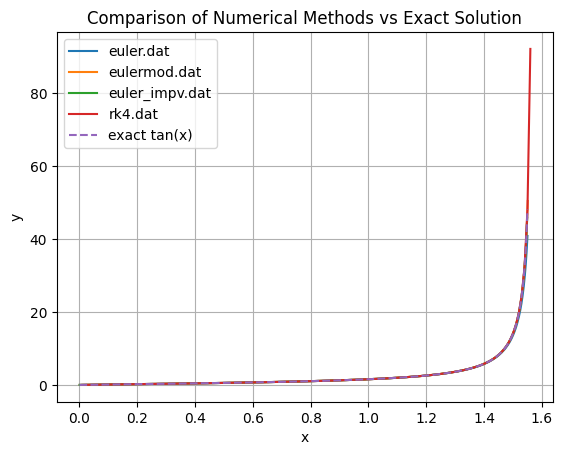

In [43]:
import matplotlib.pyplot as plt
import numpy as np

files = [
    'euler.dat',
    'eulermod.dat',

    'euler_impv.dat',
    'rk4.dat'
]

# Plot numerical solutions
for f in files:
    x = []
    y = []
    with open(f, 'r') as file:
        for line in file:
            parts = line.split()
            if len(parts) >= 3:
                x.append(float(parts[1]))
                y.append(float(parts[2]))

    plt.plot(x, y, label=f)

# Exact solution
x_exact = np.linspace(0, 1.55, 2000)
y_exact = np.tan(x_exact)

plt.plot(x_exact, y_exact, linestyle='dashed', label='exact tan(x)')

# plt.xlim(0,0.4)
# plt.ylim(0,0.005)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of Numerical Methods vs Exact Solution')
plt.legend()
plt.grid()

plt.show()

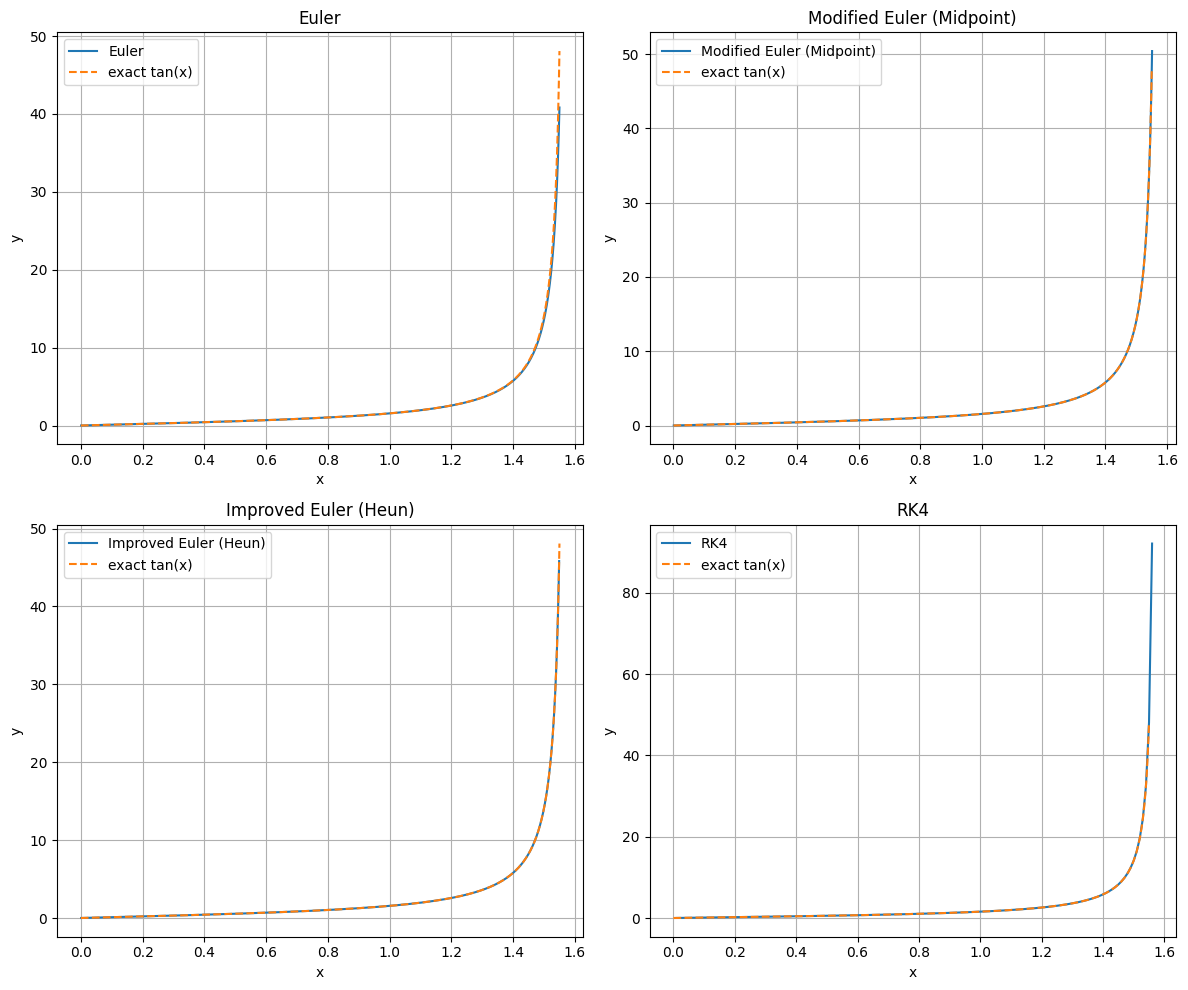

In [44]:
import matplotlib.pyplot as plt
import numpy as np

files = [
    ('euler.dat', 'Euler'),
    ('eulermod.dat', 'Modified Euler (Midpoint)'),
    ('euler_impv.dat', 'Improved Euler (Heun)'),
    ('rk4.dat', 'RK4')
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Exact solution
x_exact = np.linspace(0, 1.55, 2000)
y_exact = np.tan(x_exact)

axes = axes.flatten()

for idx, (file, title) in enumerate(files):
    x = []
    y = []

    with open(file, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 3:
                x.append(float(parts[1]))
                y.append(float(parts[2]))

    x = np.array(x)
    y = np.array(y)

    ax = axes[idx]

    # numerical
    ax.plot(x, y, label=title)

    # exact
    ax.plot(x_exact, y_exact, linestyle='dashed', label='exact tan(x)')

    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

In [45]:
import numpy as np

files = [
    'euler.dat',
    'eulermod.dat',

    'euler_impv.dat',
    'rk4.dat'
]

x_target = 1.55

print(f"{'Method':<15} {'y(1.55)':<20} {'Error':<20}")

for f in files:
    x_vals = []
    y_vals = []

    with open(f, 'r') as file:
        for line in file:
            parts = line.split()
            if len(parts) >= 3:
                x_vals.append(float(parts[1]))
                y_vals.append(float(parts[2]))

    x_vals = np.array(x_vals)
    y_vals = np.array(y_vals)

    # Find closest x to 1.55
    idx = np.argmin(np.abs(x_vals - x_target))

    y_num = y_vals[idx]
    y_exact = np.tan(x_vals[idx])

    error = abs(y_num - y_exact)

    print(f"{f:<15} {y_num:<20.10f} {error:<20.10f}")

print(f"True value at x=1.55 is : {np.tan(1.55)}")


Method          y(1.55)              Error               
euler.dat       40.8304780142        7.2481747173        
eulermod.dat    48.0009453860        0.0775370932        
euler_impv.dat  45.8272534837        0.0449258283        
rk4.dat         48.0500659897        0.0283363712        
True value at x=1.55 is : 48.07848247921907


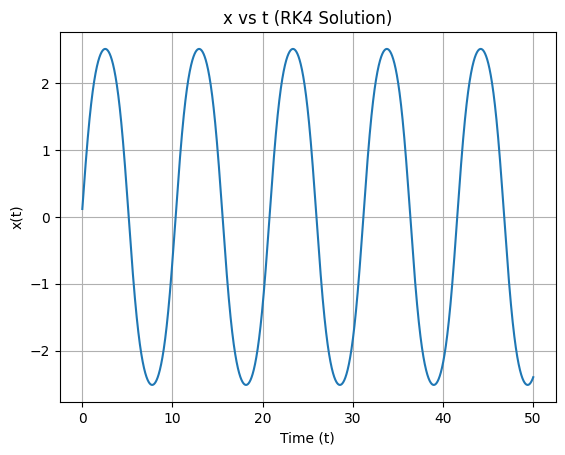

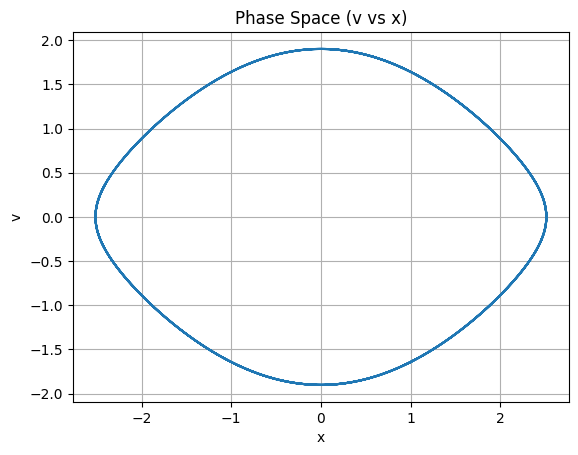

Value of x at T=50 : -2.3993325934678293 for x0=0.9 , v=1.9 


In [46]:
import numpy as np
import matplotlib.pyplot as plt

t = []
x = []

with open('couple.dat', 'r') as f:
    for line in f:
        parts = line.split()
        if len(parts) >= 3:
            t.append(float(parts[1]))  # time
            x.append(float(parts[2]))  # x

t = np.array(t)
x = np.array(x)

plt.plot(t, x)

plt.xlabel('Time (t)')
plt.ylabel('x(t)')
plt.title('x vs t (RK4 Solution)')
plt.grid()

plt.show()



v = []

with open('couple.dat', 'r') as f:
    for line in f:
        parts = line.split()
        if len(parts) >= 4:
            v.append(float(parts[3]))

v = np.array(v)

plt.plot(x, v)
plt.xlabel('x')
plt.ylabel('v')
plt.title('Phase Space (v vs x)')
plt.grid()
plt.show()
print(f"Value of x at T=50 : {x[-1]} for x0=0.9 , v=1.9 ")

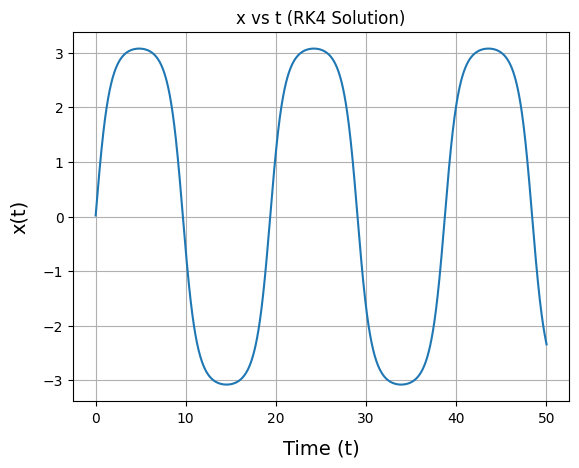

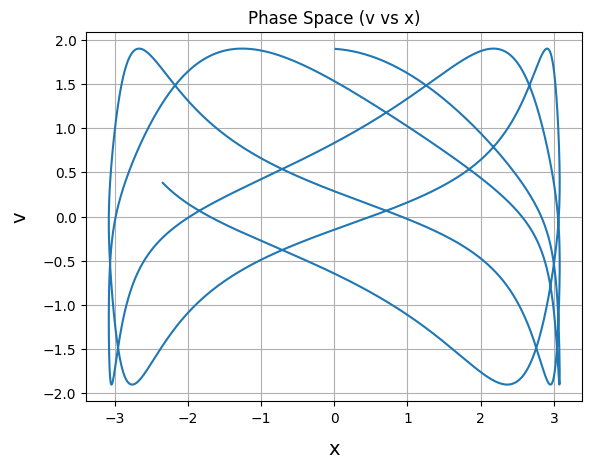

Value of x at T=50 : -2.3412238000431116 for x0=0 , v0= 1.999


In [53]:
import numpy as np
import matplotlib.pyplot as plt

t = []
x = []

with open('couple1.dat', 'r') as f:
    for line in f:
        parts = line.split()
        if len(parts) >= 3:
            t.append(float(parts[1]))  # time
            x.append(float(parts[2]))  # x

t = np.array(t)
x = np.array(x)

plt.plot(t, x)

plt.xlabel('Time (t)',fontsize=14,labelpad=10)
plt.ylabel('x(t)',fontsize=14,labelpad=10)
plt.title('x vs t (RK4 Solution)')
plt.grid()

plt.show()



v = []

with open('couple.dat', 'r') as f:
    for line in f:
        parts = line.split()
        if len(parts) >= 4:
            v.append(float(parts[3]))

v = np.array(v)

plt.plot(x, v)
plt.xlabel('x',fontsize=14,labelpad=10)
plt.ylabel('v',fontsize=14,labelpad=10)
plt.title('Phase Space (v vs x)')
plt.grid()
plt.show()
print(f"Value of x at T=50 : {x[-1]} for x0=0 , v0= 1.999")

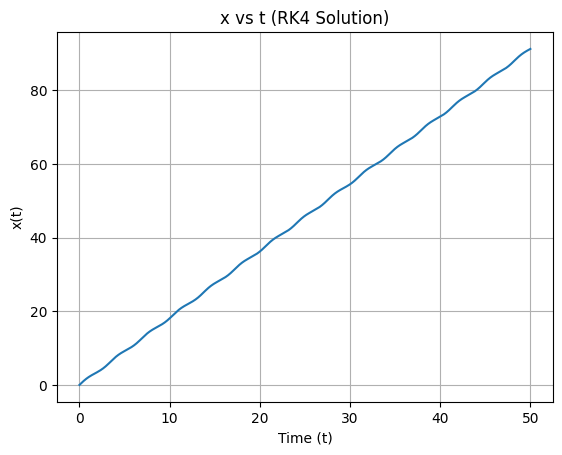

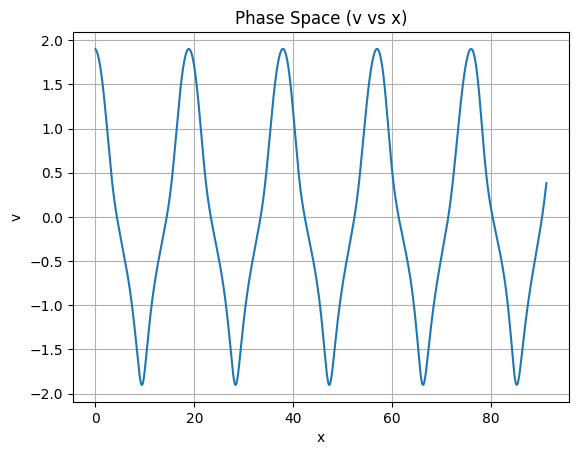

Value of x at T=50 : 91.17432446478745 for x0=0 . v0=2.4


In [48]:
import numpy as np
import matplotlib.pyplot as plt

t = []
x = []

with open('couple2.dat', 'r') as f:
    for line in f:
        parts = line.split()
        if len(parts) >= 3:
            t.append(float(parts[1]))  # time
            x.append(float(parts[2]))  # x

t = np.array(t)
x = np.array(x)

plt.plot(t, x)

plt.xlabel('Time (t)')
plt.ylabel('x(t)')
plt.title('x vs t (RK4 Solution)')
plt.grid()

plt.show()



v = []

with open('couple.dat', 'r') as f:
    for line in f:
        parts = line.split()
        if len(parts) >= 4:
            v.append(float(parts[3]))

v = np.array(v)

plt.plot(x, v)
plt.xlabel('x')
plt.ylabel('v')
plt.title('Phase Space (v vs x)')
plt.grid()
plt.show()
print(f"Value of x at T=50 : {x[-1]} for x0=0 . v0=2.4")

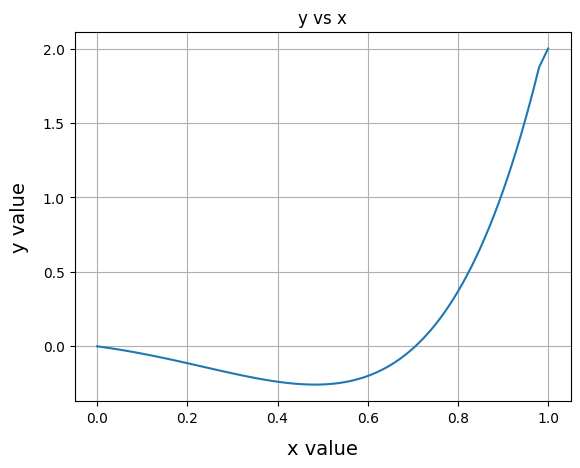

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# load data
data = np.loadtxt('diff.dat')

# split columns
x = data[:, 0]
y = data[:, 1]

# plot
plt.plot(x, y)

plt.xlabel('x value',fontsize=14,labelpad=10)
plt.ylabel('y value',fontsize=14,labelpad=10)
plt.title('y vs x')
plt.grid()

plt.show()

#  no of grid points         100
#  No. of iterations to achieve convergence =        3912
#  Value of y at x=0.80 is :  0.36787301598290084


At t=40:
y1  = -0.11891893262315607
y40 = -0.005328767596945476


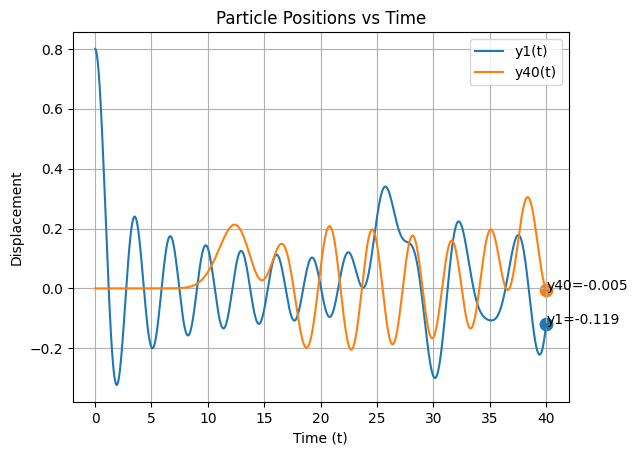

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# load data
t, y1, y26, y40 = np.loadtxt('part1.dat', unpack=True)

# plot curves
plt.plot(t, y1, label='y1(t)')

plt.plot(t, y40, label='y40(t)')

# highlight t = 40
t_target = 40.0
idx = np.argmin(np.abs(t - t_target))

# scatter points
plt.scatter(t[idx], y1[idx], s=80)

plt.scatter(t[idx], y40[idx], s=80)

# annotate
plt.text(t[idx], y1[idx], f"y1={y1[idx]:.3f}")

plt.text(t[idx], y40[idx], f"y40={y40[idx]:.3f}")

# print values
print(f"At t=40:")
print(f"y1  = {y1[idx]}")

print(f"y40 = {y40[idx]}")

plt.xlabel('Time (t)')
plt.ylabel('Displacement')
plt.title('Particle Positions vs Time')
plt.legend()
plt.grid()

plt.show()

Temperature at (20,20) = 1.7791982400306057


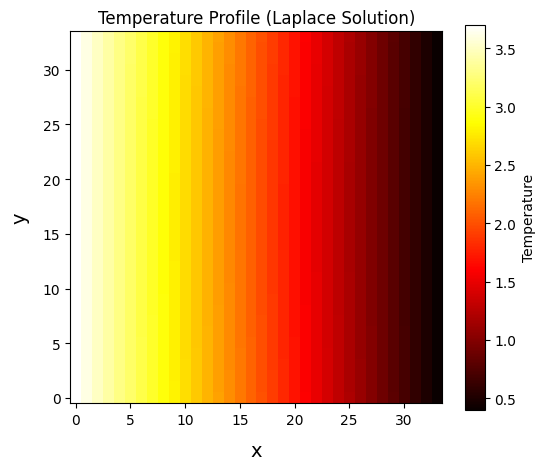

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# load data
data = np.loadtxt('laplace.dat')

# extract columns
i = data[:,0].astype(int)
j = data[:,1].astype(int)
T = data[:,2]

# grid size
lx, ly = 34, 34

# create grid
grid = np.zeros((lx, ly))

# fill grid
for k in range(len(T)):
    grid[i[k]-1, j[k]-1] = T[k]

# print temperature at (20,20)
print(f"Temperature at (20,20) = {grid[19,19]}")

# plot heatmap
plt.figure(figsize=(6,5))
plt.imshow(grid.T, origin='lower', cmap='hot', aspect='equal')
plt.colorbar(label='Temperature')

plt.xlabel('x',fontsize=14,labelpad=10)
plt.ylabel('y',fontsize=14,labelpad=10)
plt.title('Temperature Profile (Laplace Solution)')



plt.show()

Temperature at (10,10) = 1550.1274032835956


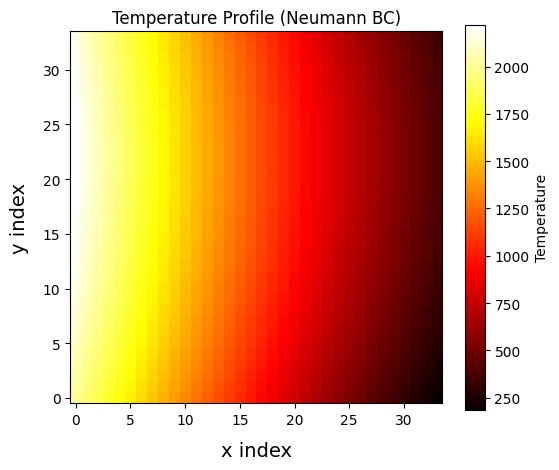

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# load file
data = np.loadtxt('neumann.dat')

# extract columns
i = data[:,0].astype(int)
j = data[:,1].astype(int)
T = data[:,2]

# grid size
lx, ly = 34, 34

# create grid
grid = np.zeros((lx, ly))

# fill grid (convert Fortran -> Python indexing)
for k in range(len(T)):
    grid[i[k]-1, j[k]-1] = T[k]

# ---------------- VALUE AT (10,10) ----------------
print(f"Temperature at (10,10) = {grid[9,9]}")

# ---------------- HEATMAP ----------------
plt.figure(figsize=(6,5))

plt.imshow(grid.T, origin='lower', cmap='hot', aspect='equal')
plt.colorbar(label='Temperature')

plt.xlabel('x index',fontsize=14,labelpad=10)
plt.ylabel('y index',fontsize=14,labelpad=10)
plt.title('Temperature Profile (Neumann BC)')



plt.show()